**Visualisasi Projek Probabilitas dan Statistika**

In [2]:
# LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("import berhasil")

import berhasil


In [3]:
from google.colab import files

uploaded = files.upload()

Saving 3TIC_06_DataAntrean.xlsx to 3TIC_06_DataAntrean.xlsx


**Pengaturan Tampilan Grafik** (supaya seluruh gambar seragam)

In [4]:
# PENGATURAN TAMPILAN GRAFIK
BIRU, ORANYE = "#2A78D6", "#EB6834"

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.linestyle": "--", "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

**Memuat Data dan Eksplorasi Awal**

In [7]:
# Membaca data dari sheet Data_Antrean
df = pd.read_excel("3TIC_06_DataAntrean.xlsx", sheet_name="Data_Antrean")
print("Ukuran dataset:", df.shape)

# Menampilkan 5 data pertama
df.head()

Ukuran dataset: (946, 6)


,timestamp,hour,queue_size,recent_avg_wait_time,actual_wait,day_of_week
0,2026-08-04 13:55:00,13,0,6.77,6.77,1
1,2026-08-04 13:57:00,13,1,8.42,10.07,1
2,2026-08-04 13:58:00,13,1,8.76,9.43,1
3,2026-08-04 14:01:00,14,1,10.64,16.30,1
4,2026-08-04 14:05:00,14,1,11.67,15.80,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946 entries, 0 to 945
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             946 non-null    datetime64[ns]
 1   hour                  946 non-null    int64         
 2   queue_size            946 non-null    int64         
 3   recent_avg_wait_time  946 non-null    float64       
 4   actual_wait           946 non-null    float64       
 5   day_of_week           946 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 44.5 KB


In [9]:
df.describe()

,timestamp,hour,queue_size,recent_avg_wait_time,actual_wait,day_of_week
count,946,946.000000,946.000000,946.000000,946.000000,946.000000
mean,2026-08-10 07:04:08.946088704,15.417548,0.599366,20.322252,17.416078,3.371036
min,2026-08-04 13:55:00,10.000000,0.000000,3.570000,3.500000,0.000000
25%,2026-08-08 12:17:28.500000,14.000000,0.000000,13.937500,5.800000,2.000000
50%,2026-08-09 17:32:02.500000,16.000000,0.000000,19.005000,9.630000,3.000000
75%,2026-08-12 17:24:58.750000128,17.000000,1.000000,24.235000,21.175000,5.000000
max,2026-08-16 18:59:35,20.000000,5.000000,79.270000,99.670000,6.000000
std,NaN,2.311249,0.758137,10.008865,18.355605,2.076007


**Pra-pemrosesan Data** (missing value dan duplikat)

In [10]:
print("--- Missing value per kolom ---")
print(df.isnull().sum())

--- Missing value per kolom ---
timestamp               0
hour                    0
queue_size              0
recent_avg_wait_time    0
actual_wait             0
day_of_week             0
dtype: int64


In [11]:
print("--- Data duplikat ---")
print("Jumlah baris duplikat:", df.duplicated().sum())

--- Data duplikat ---
Jumlah baris duplikat: 0


Pemeriksaan outlier (IQR)

In [12]:
# PEMERIKSAAN OUTLIER (metode IQR)
# Outlier = nilai di atas Q3 + 1,5 x IQR atau di bawah Q1 - 1,5 x IQR
vars_utama = ["queue_size", "recent_avg_wait_time", "actual_wait"]

baris = []
for v in vars_utama:
    q1, q3 = df[v].quantile([0.25, 0.75])
    iqr = q3 - q1
    bawah, atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[v] < bawah) | (df[v] > atas)).sum()
    baris.append([v, q1, q3, iqr, bawah, atas, n_out, n_out / len(df) * 100])

tabel_outlier = pd.DataFrame(baris, columns=["Variabel", "Q1", "Q3", "IQR",
                             "Batas bawah", "Batas atas", "Jumlah outlier", "Persen (%)"]).round(2)
tabel_outlier

,Variabel,Q1,Q3,IQR,Batas bawah,Batas atas,Jumlah outlier,Persen (%)
0,queue_size,0.00,1.00,1.00,-1.50,2.50,19,2.01
1,recent_avg_wait_time,13.94,24.24,10.30,-1.51,39.68,36,3.81
2,actual_wait,5.80,21.18,15.38,-17.26,44.24,82,8.67


**BAB 4.1 Statistika Deskriptif**

In [14]:
# STATISTIK DESKRIPTIF 3 VARIABEL UTAMA
tabel_desk = df[vars_utama].describe().T.round(2)
tabel_desk["skewness"] = df[vars_utama].skew().round(2)
tabel_desk = tabel_desk.rename(columns={"25%": "Q1", "50%": "median", "75%": "Q3"})
tabel_desk

,count,mean,std,min,Q1,median,Q3,max,skewness
queue_size,946.0,0.60,0.76,0.00,0.00,0.00,1.00,5.00,1.22
recent_avg_wait_time,946.0,20.32,10.01,3.57,13.94,19.00,24.24,79.27,1.60
actual_wait,946.0,17.42,18.36,3.50,5.80,9.63,21.18,99.67,2.10


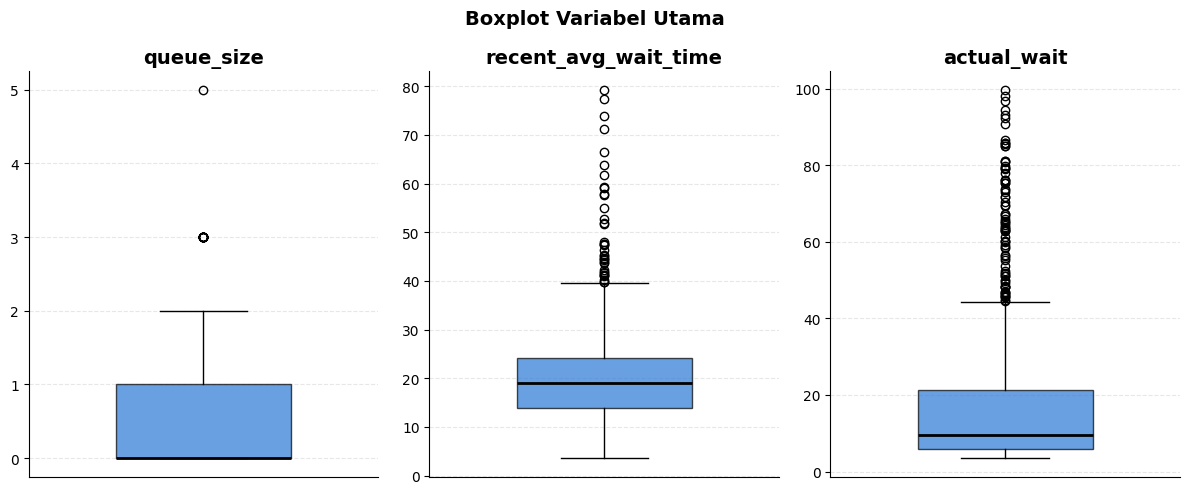

In [19]:
# BOXPLOT 3 VARIABEL UTAMA
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, v in zip(axes, vars_utama):
    ax.boxplot(df[v], patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=BIRU, alpha=0.7),
               medianprops=dict(color="black", linewidth=2))
    ax.set_title(v)
    ax.set_xticks([])

plt.suptitle("Boxplot Variabel Utama", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Distribusi Jumlah Orang dalam Antrean (queue_size)**

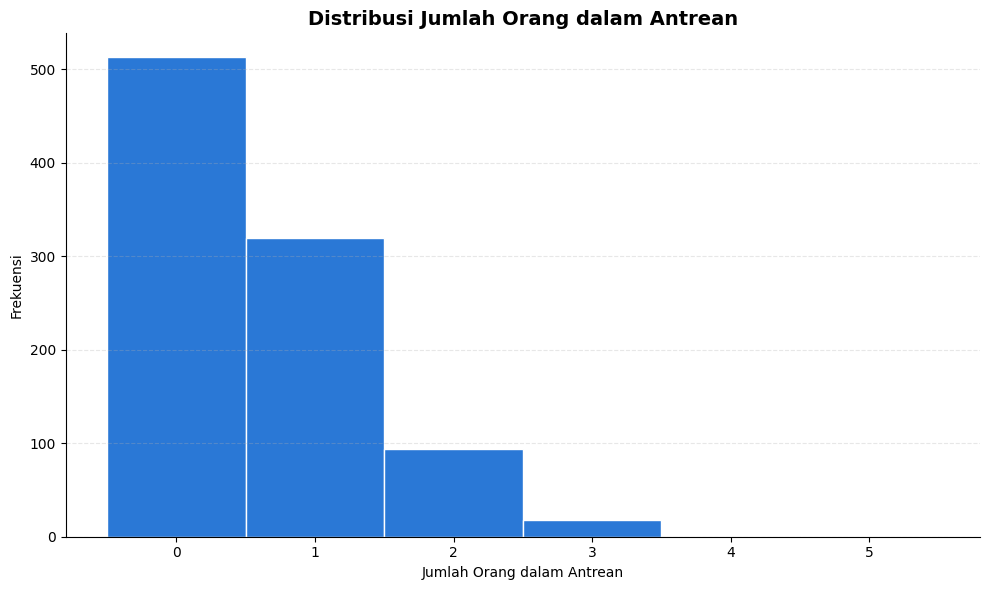

In [18]:
# HISTOGRAM queue_size
plt.hist(df["queue_size"], bins=np.arange(-0.5, 6.5, 1), color=BIRU, edgecolor="white")
plt.xticks(range(0, 6))
plt.title("Distribusi Jumlah Orang dalam Antrean")
plt.xlabel("Jumlah Orang dalam Antrean")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

lambda (rata-rata) = 0.599 | varians = 0.575
queue_size  Pengamatan  Harapan Poisson
         0         513            519.5
         1         320            311.4
         2          94             93.3
       >=3          19             21.8
Chi-square = 0.687 | p-value = 0.709


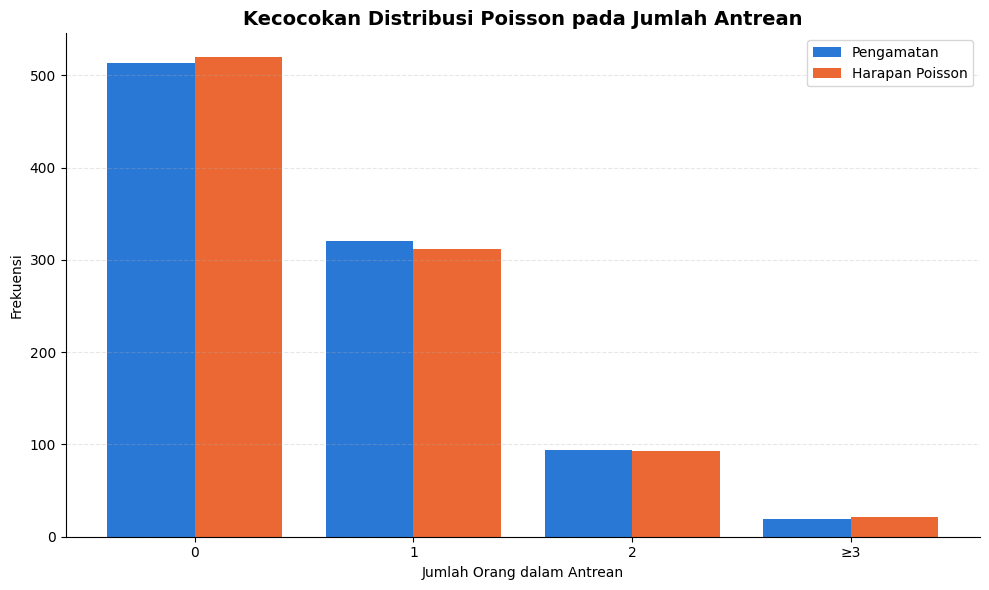

In [20]:
# KECOCOKAN DISTRIBUSI POISSON (queue_size)
lam = df["queue_size"].mean()
n = len(df)
print(f"lambda (rata-rata) = {lam:.3f} | varians = {df['queue_size'].var():.3f}")

# Frekuensi pengamatan (antrean 3 ke atas digabung karena datanya sedikit)
obs = [(df["queue_size"] == k).sum() for k in [0, 1, 2]] + [(df["queue_size"] >= 3).sum()]

# Frekuensi harapan menurut distribusi Poisson
prob = [stats.poisson.pmf(k, lam) for k in [0, 1, 2]]
prob.append(1 - sum(prob))
harapan = [p * n for p in prob]

# Uji chi-square (ddof=1 karena lambda diestimasi dari data)
chi2, p_chi = stats.chisquare(obs, harapan, ddof=1)

tabel_poisson = pd.DataFrame({
    "queue_size": ["0", "1", "2", ">=3"],
    "Pengamatan": obs,
    "Harapan Poisson": np.round(harapan, 1)
})
print(tabel_poisson.to_string(index=False))
print(f"Chi-square = {chi2:.3f} | p-value = {p_chi:.3f}")

x = np.arange(4)
plt.bar(x - 0.2, obs, width=0.4, color=BIRU, label="Pengamatan")
plt.bar(x + 0.2, harapan, width=0.4, color=ORANYE, label="Harapan Poisson")
plt.xticks(x, ["0", "1", "2", "\u22653"])
plt.title("Kecocokan Distribusi Poisson pada Jumlah Antrean")
plt.xlabel("Jumlah Orang dalam Antrean")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()

**Distribusi Waktu Tunggu Aktual (actual_wait)**

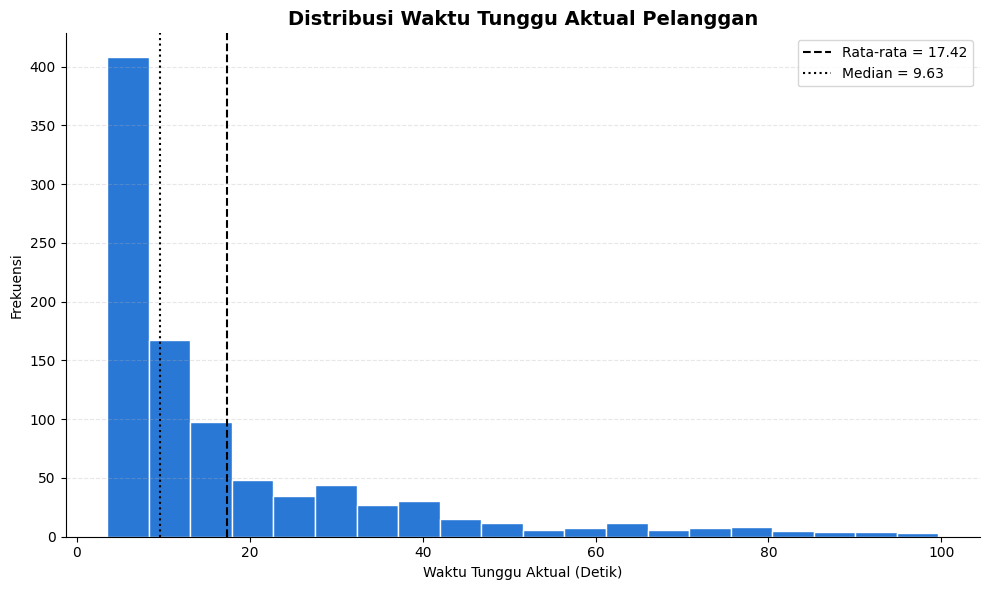

In [21]:
# HISTOGRAM actual_wait
rata = df["actual_wait"].mean()
med = df["actual_wait"].median()

plt.hist(df["actual_wait"], bins=20, color=BIRU, edgecolor="white")
plt.axvline(rata, color="black", linestyle="--", label=f"Rata-rata = {rata:.2f}")
plt.axvline(med, color="black", linestyle=":", label=f"Median = {med:.2f}")
plt.title("Distribusi Waktu Tunggu Aktual Pelanggan")
plt.xlabel("Waktu Tunggu Aktual (Detik)")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()

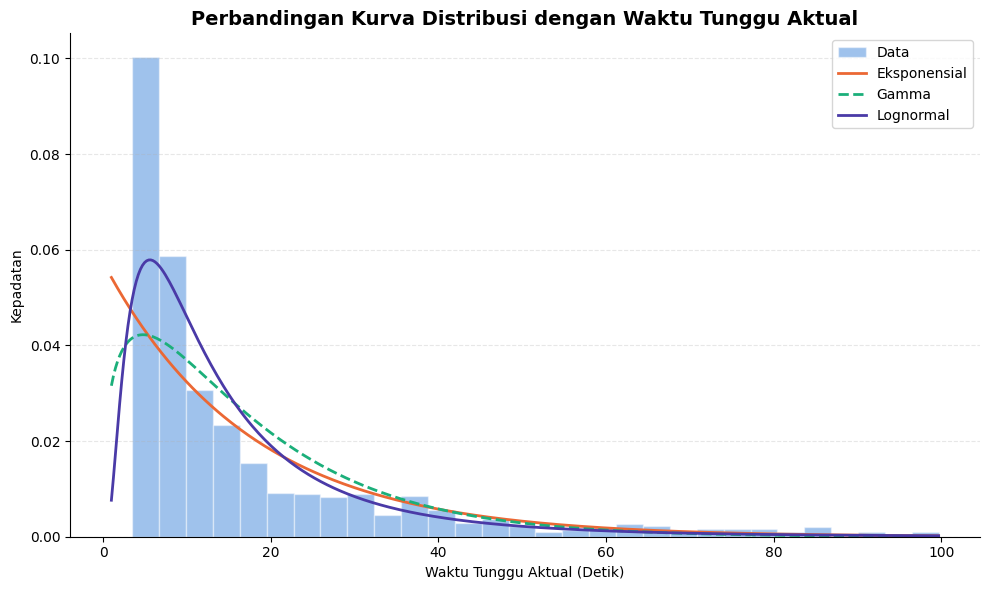

In [22]:
# KURVA DISTRIBUSI vs HISTOGRAM actual_wait
w = df["actual_wait"]
kandidat = {
    "Eksponensial": (stats.expon,   "#EB6834", "-"),
    "Gamma":        (stats.gamma,   "#1BAF7A", "--"),
    "Lognormal":    (stats.lognorm, "#4A3AA7", "-"),
}

xs = np.linspace(1, w.max(), 400)
plt.hist(w, bins=30, density=True, color=BIRU, alpha=0.45, edgecolor="white", label="Data")

for nama, (dist, warna, gaya) in kandidat.items():
    param = dist.fit(w, floc=0)          # estimasi parameter distribusi dari data
    plt.plot(xs, dist.pdf(xs, *param), color=warna, linestyle=gaya, linewidth=2, label=nama)

plt.title("Perbandingan Kurva Distribusi dengan Waktu Tunggu Aktual")
plt.xlabel("Waktu Tunggu Aktual (Detik)")
plt.ylabel("Kepadatan")
plt.legend()
plt.tight_layout()
plt.show()

**Distribusi Rata-Rata Waktu Tunggu Sebelumnya (recent_avg_wait_time)**

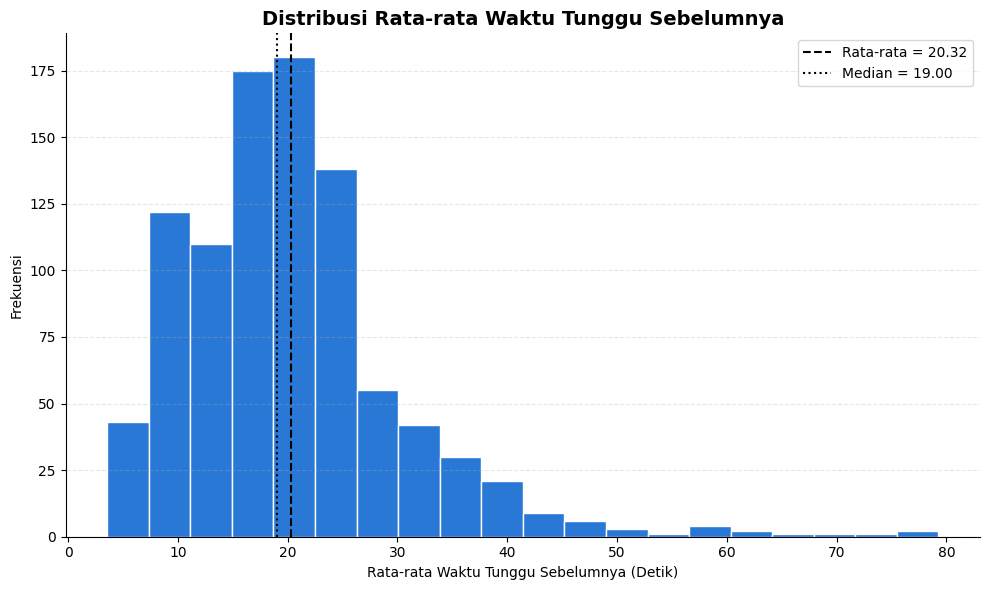

In [23]:
# HISTOGRAM recent_avg_wait_time
rata = df["recent_avg_wait_time"].mean()
med = df["recent_avg_wait_time"].median()

plt.hist(df["recent_avg_wait_time"], bins=20, color=BIRU, edgecolor="white")
plt.axvline(rata, color="black", linestyle="--", label=f"Rata-rata = {rata:.2f}")
plt.axvline(med, color="black", linestyle=":", label=f"Median = {med:.2f}")
plt.title("Distribusi Rata-rata Waktu Tunggu Sebelumnya")
plt.xlabel("Rata-rata Waktu Tunggu Sebelumnya (Detik)")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()

**Hubungan Jumlah Antrean terhadap Waktu Tunggu Aktual**

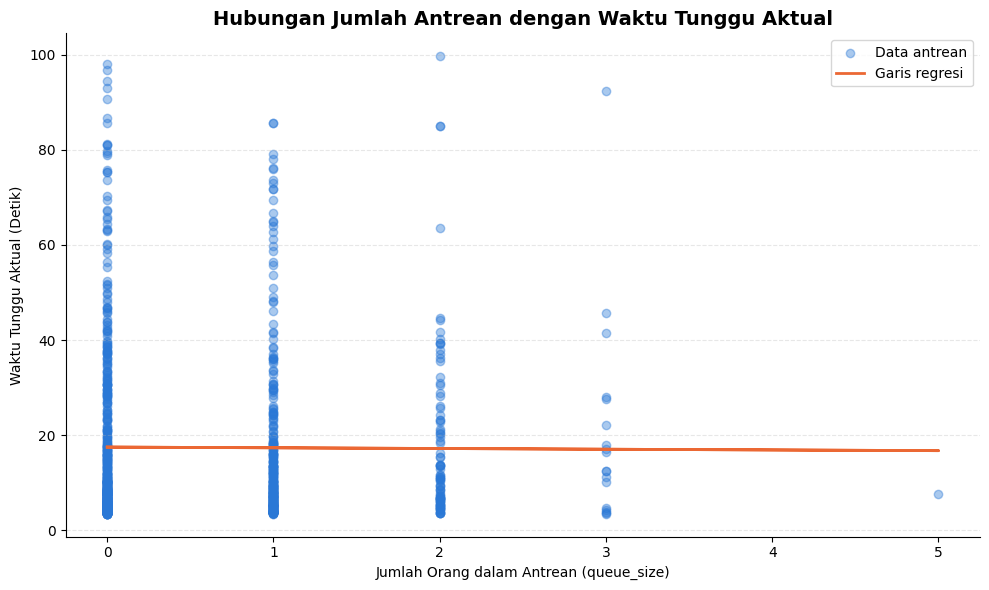

r = -0.006 | p-value = 0.848


In [24]:
# SCATTER PLOT queue_size vs actual_wait
x = df["queue_size"]
y = df["actual_wait"]
reg = stats.linregress(x, y)

plt.scatter(x, y, alpha=0.4, color=BIRU, label="Data antrean")
plt.plot(x, reg.intercept + reg.slope * x, color=ORANYE, linewidth=2, label="Garis regresi")
plt.xticks(range(0, 6))
plt.title("Hubungan Jumlah Antrean dengan Waktu Tunggu Aktual")
plt.xlabel("Jumlah Orang dalam Antrean (queue_size)")
plt.ylabel("Waktu Tunggu Aktual (Detik)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"r = {reg.rvalue:.3f} | p-value = {reg.pvalue:.3f}")

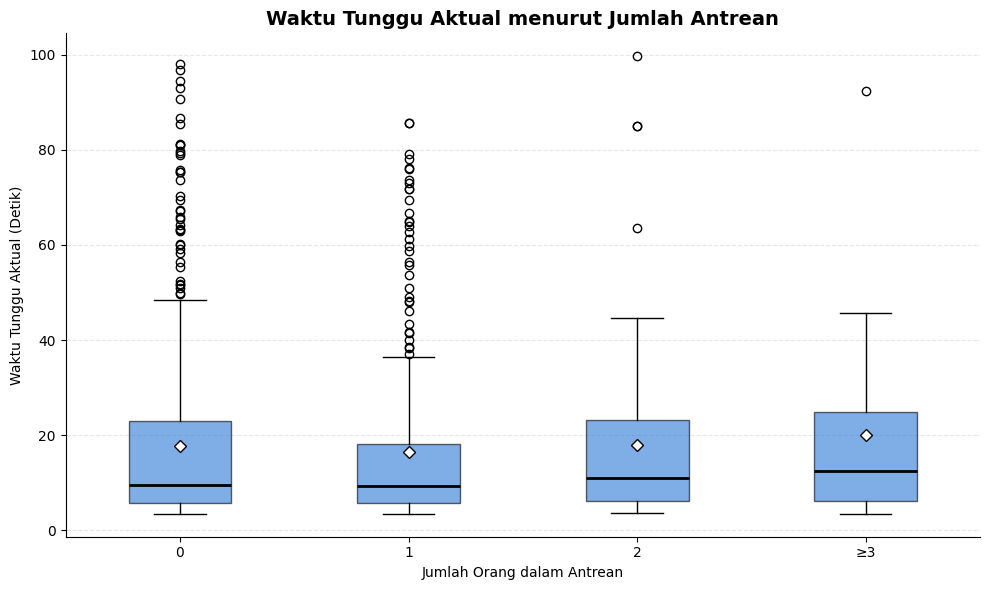

    count   mean  median
0     513  17.84    9.50
1     320  16.40    9.40
2      94  17.99   10.95
≥3     19  20.15   12.43
ANOVA satu arah: F = 0.591 | p-value = 0.621


In [25]:
# WAKTU TUNGGU PER KELOMPOK ANTREAN + ANOVA
# Antrean 3, 4, 5 digabung menjadi ">=3" karena datanya sedikit
df["kelompok"] = df["queue_size"].clip(upper=3)
label = ["0", "1", "2", "\u22653"]
grup = [df.loc[df["kelompok"] == k, "actual_wait"] for k in range(4)]

plt.boxplot(grup, patch_artist=True, showmeans=True,
            boxprops=dict(facecolor=BIRU, alpha=0.6),
            medianprops=dict(color="black", linewidth=2),
            meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black"))
plt.xticks([1, 2, 3, 4], label)
plt.title("Waktu Tunggu Aktual menurut Jumlah Antrean")
plt.xlabel("Jumlah Orang dalam Antrean")
plt.ylabel("Waktu Tunggu Aktual (Detik)")
plt.tight_layout()
plt.show()

# Ringkasan per kelompok
ringkas = df.groupby("kelompok")["actual_wait"].agg(["count", "mean", "median"]).round(2)
ringkas.index = label
print(ringkas)

# ANOVA satu arah
f, p_anova = stats.f_oneway(*grup)
print(f"ANOVA satu arah: F = {f:.3f} | p-value = {p_anova:.3f}")

**Hubungan Rata-Rata Waktu Tunggu Sebelumnya terhadap Waktu Tunggu Aktual**

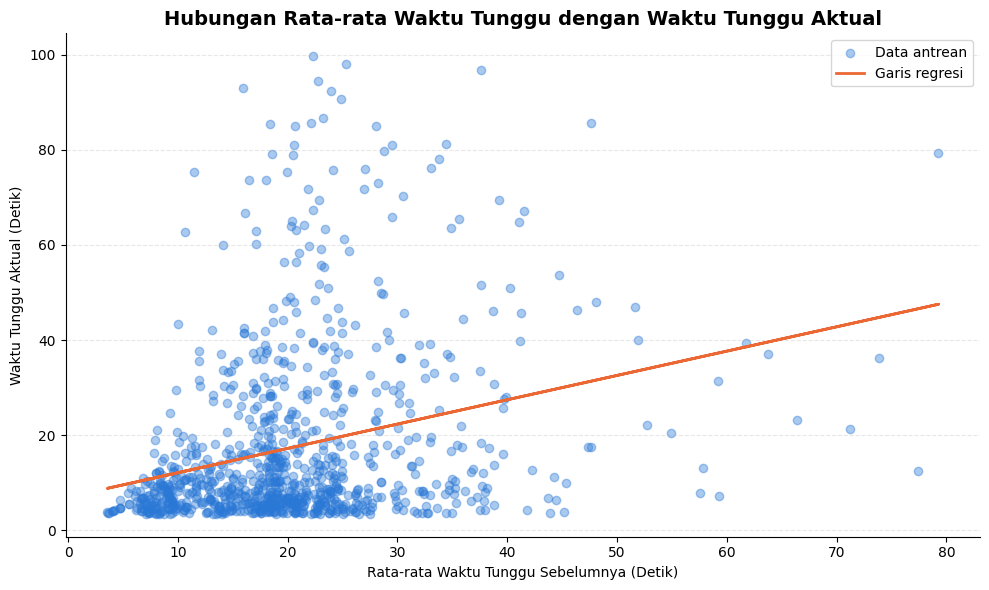

Korelasi Pearson (r) = 0.279 | p-value = 2.44e-18
Persamaan regresi    : actual_wait = 7.03 + 0.511 x recent_avg_wait_time
R-kuadrat (R2)       = 0.078 (7.8% variasi dijelaskan)


In [27]:
# SCATTER, KORELASI, DAN REGRESI recent_avg_wait_time vs actual_wait
x = df["recent_avg_wait_time"]
y = df["actual_wait"]
reg = stats.linregress(x, y)

plt.scatter(x, y, alpha=0.4, color=BIRU, label="Data antrean")
plt.plot(x, reg.intercept + reg.slope * x, color=ORANYE, linewidth=2, label="Garis regresi")
plt.title("Hubungan Rata-rata Waktu Tunggu dengan Waktu Tunggu Aktual")
plt.xlabel("Rata-rata Waktu Tunggu Sebelumnya (Detik)")
plt.ylabel("Waktu Tunggu Aktual (Detik)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Korelasi Pearson (r) = {reg.rvalue:.3f} | p-value = {reg.pvalue:.2e}")
print(f"Persamaan regresi    : actual_wait = {reg.intercept:.2f} + {reg.slope:.3f} x recent_avg_wait_time")
print(f"R-kuadrat (R2)       = {reg.rvalue**2:.3f} ({reg.rvalue**2*100:.1f}% variasi dijelaskan)")